In [1]:
from pathlib import Path
import os

from import_libraries import *  # NOSONAR
from global_variables import *  # NOSONAR
import common_libraries.io_library as io_l

from ml_classification.ml_classification_pipeline import (
    GeospatialClassificationPipeline,
    ClassificationPipelineConfig,
)

c:\ProgramData\anaconda3\envs\axhub_spatial\Lib\site-packages\xicor\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [ ]:
WORK_PATH = Path("C:/work_dir/volvi-2023-2024")

PARCELS_PATH = WORK_PATH / "1_parcel_stats" / "satellite_parcel_time_stats.geoparquet"
OUTPUT_PATH = WORK_PATH / "3_ml_classification"

class_column = "label_gr"
parcel_id_column = "parcel_code"


In [3]:
gdf_parcels = io_l.read_data(str(PARCELS_PATH))
gdf_parcels.head(3)

Reading file: C:/work_dir/volvi-2023-2024/1_parcel_stats/satellite_parcel_time_stats.geoparquet


parcel_code  initial_label_code  initial_label  predicted_label_code  \
0   277666994                 119  grass_fodders                  129    
1   277666938                 119  grass_fodders                  111    
2   277666942                 119  grass_fodders                  111    

  predicted_label  prediction_probability set_type             label_gr  \
0          fallow         0.3141156000       train  χορτοδοτικές καλ...   
1          barley         0.2663752700        test  χορτοδοτικές καλ...   
2          barley         0.1837388100        test  χορτοδοτικές καλ...   

              geometry  batch_number  eligible_pixel_count  \
0  POLYGON ((422211...             1                   51    
1  POLYGON ((422390...             1                  284    
2  POLYGON ((422372...             1                   76    

   meets_minimum_pixel_count   parcel_area_m2  approx_pixel_count  \
0                 True        4981.3191093498       49.8131910935   
1                 True       28418.2862207056      284.1828622071   
2                 True        7917.8669660429       79.1786696604   

   B02_bowley_skewness__20231001  B02_bowley_skewness__20231101  \
0         0.5117773416                   0.5999997639             
1         0.1031400682                   0.0322586072             
2         0.0798121475                   0.1960771996             

   B02_bowley_skewness__20231201  B02_bowley_skewness__20240101  \
0         0.3978494279                   0.2454546378             
1        -0.0666653421                   0.1333331678             
2        -0.0676714306                   0.0931665636             

   B02_bowley_skewness__20240201  B02_bowley_skewness__20240301  \
0         0.5669516885                   0.6146969834             
1        -0.0625010186                   0.1210192775             
2         0.2307692308                   0.0825681677             

   B02_bowley_skewness__20240401  B02_bowley_skewness__20240501  \
0         0.7050764318                  -0.2736318113             
1         0.1111108812                   0.1538430678             
2         0.2478635309                   0.1862058476             

   B02_bowley_skewness__20240601  B02_bowley_skewness__20240701  \
0        -0.3769234318                  -0.1985817477             
1        -0.0238465934                   0.0482766559             
2         0.0272938907                   0.5614613434             

   B02_bowley_skewness__20240801  B02_bowley_skewness__20240901  \
0        -0.6771299969                   0.3383459489             
1         0.1914895303                   0.0018340737             
2         0.5565610280                  -0.1636364030             

   B02_coefficient_of_variation__20231001  \
0         0.1824705458                      
1         0.2607599191                      
2         0.1337565364                      

   B02_coefficient_of_variation__20231101  \
0         0.2420751266                      
1         0.0576393047                      
2         0.0360361668                      

   B02_coefficient_of_variation__20231201  \
0         0.1398290159                      
1         0.0593364068                      
2         0.0589725506                      

   B02_coefficient_of_variation__20240101  \
0         0.1413026988                      
1         0.0699844535                      
2         0.0709658211                      

   B02_coefficient_of_variation__20240201  \
0         0.2568934227                      
1         0.0862012018                      
2         0.0536342085                      

   B02_coefficient_of_variation__20240301  \
0         0.4053427945                      
1         0.1178632265                      
2         0.1121456810                      

   B02_coefficient_of_variation__20240401  \
0         0.3345281127                      
1         0.1142292387                      
2         0.1376408609                     

In [4]:
label_counts = gdf_parcels[class_column].value_counts()
rare_labels = label_counts[label_counts < 100].index

gdf_parcels.loc[gdf_parcels[class_column].isin(rare_labels), class_column] = "9999"
print(gdf_parcels[class_column].value_counts())

label_gr
σιτάρι                       11140
χορτοδοτικές καλλιέργειες     6128
κριθάρι                       3911
αραβόσιτος                    2504
αγρανάπαυση                   1292
λοιπά σιτηρά                   962
ηλίανθος                       919
βαμβάκι                        531
ελαιώνες                       497
9999                           293
ελαιοκράμβη                    284
αρωματικά φυτά                 128
καρυδιές                       110
Name: count, dtype: int64


In [5]:
gdf_parcels = gdf_parcels.to_crs(2100)
gdf_parcels["x"] = gdf_parcels.centroid.x
gdf_parcels["y"] = gdf_parcels.centroid.y

base_cols = [parcel_id_column, class_column, "geometry"]
extra_features = ["elevation_mean_m", "distance_to_nearest_lake_m", "GAIOIKANOT", "x", "y"]
temporal_features = ("_median", "_sd", "_range",)
original_features = [x for x in gdf_parcels.columns if any(keyword in x for keyword in temporal_features)]

gdf_parcels = gdf_parcels[base_cols + original_features + extra_features].copy()
features = original_features + extra_features

gdf_parcels = gdf_parcels[gdf_parcels[class_column] != 9999].copy()
print(f"Final features for modeling ({len(features)} features): {features}")
display(gdf_parcels.head(3))

Final features for modeling (545 features): ['B02_median__20231001', 'B02_median__20231101', 'B02_median__20231201', 'B02_median__20240101', 'B02_median__20240201', 'B02_median__20240301', 'B02_median__20240401', 'B02_median__20240501', 'B02_median__20240601', 'B02_median__20240701', 'B02_median__20240801', 'B02_median__20240901', 'B02_range__20231001', 'B02_range__20231101', 'B02_range__20231201', 'B02_range__20240101', 'B02_range__20240201', 'B02_range__20240301', 'B02_range__20240401', 'B02_range__20240501', 'B02_range__20240601', 'B02_range__20240701', 'B02_range__20240801', 'B02_range__20240901', 'B02_sd__20231001', 'B02_sd__20231101', 'B02_sd__20231201', 'B02_sd__20240101', 'B02_sd__20240201', 'B02_sd__20240301', 'B02_sd__20240401', 'B02_sd__20240501', 'B02_sd__20240601', 'B02_sd__20240701', 'B02_sd__20240801', 'B02_sd__20240901', 'B03_median__20231001', 'B03_median__20231101', 'B03_median__20231201', 'B03_median__20240101', 'B03_median__20240201', 'B03_median__20240301', 'B03_me

,parcel_code,label_gr,geometry,B02_median__20231001,B02_median__20231101,B02_median__20231201,B02_median__20240101,B02_median__20240201,B02_median__20240301,B02_median__20240401,B02_median__20240501,B02_median__20240601,B02_median__20240701,B02_median__20240801,B02_median__20240901,B02_range__20231001,B02_range__20231101,B02_range__20231201,B02_range__20240101,B02_range__20240201,B02_range__20240301,B02_range__20240401,B02_range__20240501,B02_range__20240601,B02_range__20240701,B02_range__20240801,B02_range__20240901,B02_sd__20231001,B02_sd__20231101,B02_sd__20231201,B02_sd__20240101,B02_sd__20240201,B02_sd__20240301,B02_sd__20240401,B02_sd__20240501,B02_sd__20240601,B02_sd__20240701,B02_sd__20240801,B02_sd__20240901,B03_median__20231001,B03_median__20231101,B03_median__20231201,B03_median__20240101,B03_median__20240201,B03_median__20240301,B03_median__20240401,B03_median__20240501,B03_median__20240601,B03_median__20240701,B03_median__20240801,B03_median__20240901,B03_range__20231001,B03_range__20231101,B03_range__20231201,B03_range__20240101,B03_range__20240201,B03_range__20240301,B03_range__20240401,B03_range__20240501,B03_range__20240601,B03_range__20240701,B03_range__20240801,B03_range__20240901,B03_sd__20231001,B03_sd__20231101,B03_sd__20231201,B03_sd__20240101,B03_sd__20240201,B03_sd__20240301,B03_sd__20240401,B03_sd__20240501,B03_sd__20240601,B03_sd__20240701,B03_sd__20240801,B03_sd__20240901,B04_median__20231001,B04_median__20231101,B04_median__20231201,B04_median__20240101,B04_median__20240201,B04_median__20240301,B04_median__20240401,B04_median__20240501,B04_median__20240601,B04_median__20240701,B04_median__20240801,B04_median__20240901,B04_range__20231001,B04_range__20231101,B04_range__20231201,B04_range__20240101,B04_range__20240201,B04_range__20240301,B04_range__20240401,B04_range__20240501,B04_range__20240601,B04_range__20240701,B04_range__20240801,B04_range__20240901,B04_sd__20231001,B04_sd__20231101,B04_sd__20231201,B04_sd__20240101,B04_sd__20240201,B04_sd__20240301,B04_sd__20240401,B04_sd__20240501,B04_sd__20240601,B04_sd__20240701,B04_sd__20240801,B04_sd__20240901,B05_median__20231001,B05_median__20231101,B05_median__20231201,B05_median__20240101,B05_median__20240201,B05_median__20240301,B05_median__20240401,B05_median__20240501,B05_median__20240601,B05_median__20240701,B05_median__20240801,B05_median__20240901,B05_range__20231001,B05_range__20231101,B05_range__20231201,B05_range__20240101,B05_range__20240201,B05_range__20240301,B05_range__20240401,B05_range__20240501,B05_range__20240601,B05_range__20240701,B05_range__20240801,B05_range__20240901,B05_sd__20231001,B05_sd__20231101,B05_sd__20231201,B05_sd__20240101,B05_sd__20240201,B05_sd__20240301,B05_sd__20240401,B05_sd__20240501,B05_sd__20240601,B05_sd__20240701,B05_sd__20240801,B05_sd__20240901,B08_median__20231001,B08_median__20231101,B08_median__20231201,B08_median__20240101,B08_median__20240201,B08_median__20240301,B08_median__20240401,B08_median__20240501,B08_median__20240601,B08_median__20240701,B08_median__20240801,B08_median__20240901,B08_range__20231001,B08_range__20231101,B08_range__20231201,B08_range__20240101,B08_range__20240201,B08_range__20240301,B08_range__20240401,B08_range__20240501,B08_range__20240601,B08_range__20240701,B08_range__20240801,B08_range__20240901,B08_sd__20231001,B08_sd__20231101,B08_sd__20231201,B08_sd__20240101,B08_sd__20240201,B08_sd__20240301,B08_sd__20240401,B08_sd__20240501,B08_sd__20240601,B08_sd__20240701,B08_sd__20240801,B08_sd__20240901,B11_median__20231001,B11_median__20231101,B11_median__20231201,B11_median__20240101,B11_median__20240201,B11_median__20240301,B11_median__20240401,B11_median__20240501,B11_median__20240601,B11_median__20240701,B11_median__20240801,B11_median__20240901,B11_range__20231001,B11_range__20231101,B11_range__20231201,B11_range__20240101,B11_range__20240201,B11_range__20240301,B11_range__20240401,B11_range__20240501,B11_range__20240601,B11_range__20240701,B11_range__20240801,B11_range__202409

In [ ]:
config = ClassificationPipelineConfig(
    project_dir=OUTPUT_PATH,
    target_column=class_column,
    feature_columns=features,
    id_column=parcel_id_column,

    apply_iqr=False,
    spatial_interpolation_method=None,

    cv_folds=5,
    test_size=0.2,
    spatial_split=True,
    spatial_split_grid_size=10,
    spatial_split_method="by_row",

    random_state=SEED_NUMBER,
    # n_jobs=1,

    scoring_primary="f1_macro",
    cv_ranking_method="score_minus_std",
    selection_type="soft_voting",
    top_voting_models=5,
    max_search_candidates=40,
    prediction_confidence_threshold=0.60,

    interpretability_top_models=5,
    interpretability_include_shap=False,

    optimize_class_probabilities=True,
    probability_multiplier_grid=(0.8, 1.0, 1.2, 1.5, 2.0),
    probability_optimization_iterations=2,
    probability_optimization_max_accuracy_drop=0.02,

    rank_confidence_enabled=True,
    force_retrain_models=False,

    label_balancing_method="random_oversample",
    lstm_temporal_statistics=temporal_features,
    selected_models=(
        "bagging",
        "bayesian",
        "decision_tree",
        "extra_trees",
        "random_forest",
        "gradient_boosting",
        "lightgbm",
        "xgboost",
        "knn",
        "neural_network",
        "tensorflow_neural_network",
        "keras_lstm",
   ),
    max_map_geometries=20000,
    open_html_report=True,
)

pipeline = GeospatialClassificationPipeline(config)


In [7]:
summary_check = pipeline.run_check(df=gdf_parcels)
summary_check


Function <run_check> started on 2026-08-24 14:04:18

Checking input data...

Resetting project output folder: C:\work_dir\volvi-2023-2024\3_ml_classification
Deleting folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\01_check'...
Successfully deleted folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\01_check' on attempt 1
Deleting folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\02_prepare'...
Successfully deleted folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\02_prepare' on attempt 1
Deleting folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\03_train'...
Successfully deleted folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\03_train' on attempt 1
Deleting folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\04_evaluate'...
Successfully deleted folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\04_evaluate' on attempt 1
Deleting folder 'C:\work_dir\volvi-2023-2024\3_ml_classification\05_predict'...
Successfully deleted folder 'C:\work_di

{'rows_total': 28699,
 'rows_labeled': 28699,
 'rows_unknown_target': 0,
 'n_features_requested': 545,
 'n_features_active': 545,
 'numeric_features': ['B02_median__20231001',
  'B02_median__20231101',
  'B02_median__20231201',
  'B02_median__20240101',
  'B02_median__20240201',
  'B02_median__20240301',
  'B02_median__20240401',
  'B02_median__20240501',
  'B02_median__20240601',
  'B02_median__20240701',
  'B02_median__20240801',
  'B02_median__20240901',
  'B02_range__20231001',
  'B02_range__20231101',
  'B02_range__20231201',
  'B02_range__20240101',
  'B02_range__20240201',
  'B02_range__20240301',
  'B02_range__20240401',
  'B02_range__20240501',
  'B02_range__20240601',
  'B02_range__20240701',
  'B02_range__20240801',
  'B02_range__20240901',
  'B02_sd__20231001',
  'B02_sd__20231101',
  'B02_sd__20231201',
  'B02_sd__20240101',
  'B02_sd__20240201',
  'B02_sd__20240301',
  'B02_sd__20240401',
  'B02_sd__20240501',
  'B02_sd__20240601',
  'B02_sd__20240701',
  'B02_sd__2024080

In [8]:
summary_prepare = pipeline.run_prepare()
summary_prepare


Function <run_prepare> started on 2026-08-24 14:04:40

Preparing data...
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/02_prepare/label_mapping.csv


E:\Eleni\git_repo\satellites\src\ml_classification\ml_classification_pipeline\visuals\maps.py:156: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()



Prepared train/test split: 22959 train rows, 5740 test rows.

Execution time of function <run_prepare> ended on 2026-08-24 14:04:54 - duration: 00:00:13


{'active_features': ['B02_median__20231001',
  'B02_median__20231101',
  'B02_median__20231201',
  'B02_median__20240101',
  'B02_median__20240201',
  'B02_median__20240301',
  'B02_median__20240401',
  'B02_median__20240501',
  'B02_median__20240601',
  'B02_median__20240701',
  'B02_median__20240801',
  'B02_median__20240901',
  'B02_range__20231001',
  'B02_range__20231101',
  'B02_range__20231201',
  'B02_range__20240101',
  'B02_range__20240201',
  'B02_range__20240301',
  'B02_range__20240401',
  'B02_range__20240501',
  'B02_range__20240601',
  'B02_range__20240701',
  'B02_range__20240801',
  'B02_range__20240901',
  'B02_sd__20231001',
  'B02_sd__20231101',
  'B02_sd__20231201',
  'B02_sd__20240101',
  'B02_sd__20240201',
  'B02_sd__20240301',
  'B02_sd__20240401',
  'B02_sd__20240501',
  'B02_sd__20240601',
  'B02_sd__20240701',
  'B02_sd__20240801',
  'B02_sd__20240901',
  'B03_median__20231001',
  'B03_median__20231101',
  'B03_median__20231201',
  'B03_median__20240101',
 

In [9]:
summary_train = pipeline.run_train()
summary_train


Function <run_train> started on 2026-08-24 14:05:11

Training models...
Reading file: C:/work_dir/volvi-2023-2024/3_ml_classification/02_prepare/label_mapping.csv
____________________________________________________________________________________________________

Training model random_forest
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/03_train/models/random_forest/cv_results.csv

Saved artifacts for random_forest: model=C:\work_dir\volvi-2023-2024\3_ml_classification\03_train\models\random_forest\best_model.joblib, cv_results=C:\work_dir\volvi-2023-2024\3_ml_classification\03_train\models\random_forest\cv_results.csv, plot=C:\work_dir\volvi-2023-2024\3_ml_classification\03_train\models\random_forest\search_results.png

Model random_forest finished in duration: 00:17:33
____________________________________________________________________________________________________

Training model extra_trees
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/03_train/

c:\ProgramData\anaconda3\envs\axhub_spatial\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/03_train/models/xgboost/cv_results.csv

Saved artifacts for xgboost: model=C:\work_dir\volvi-2023-2024\3_ml_classification\03_train\models\xgboost\best_model.joblib, cv_results=C:\work_dir\volvi-2023-2024\3_ml_classification\03_train\models\xgboost\cv_results.csv, plot=C:\work_dir\volvi-2023-2024\3_ml_classification\03_train\models\xgboost\search_results.png

Model xgboost finished in duration: 01:07:20
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/03_train/training_summary.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/03_train/training_failed_models.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/03_train/best_cv_fold_scores.csv

Best CV model: xgboost using score_minus_std=0.4191

Execution time of function <run_train> ended on 2026-08-25 00:10:40 - duration: 10:05:28


{'models_trained': ['xgboost',
  'bagging',
  'extra_trees',
  'gradient_boosting',
  'random_forest',
  'neural_network'],
 'models_failed': [],
 'best_cv_model': 'xgboost',
 'cv_ranking_method': 'score_minus_std'}

In [10]:
summary_evaluate = pipeline.run_evaluate()
summary_evaluate


Function <run_evaluate> started on 2026-08-25 07:04:08

Evaluating models...
Reading file: C:/work_dir/volvi-2023-2024/3_ml_classification/02_prepare/label_mapping.csv
Reading file: C:/work_dir/volvi-2023-2024/3_ml_classification/03_train/training_summary.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/04_evaluate/reports/random_forest_classification_report.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/04_evaluate/reports/extra_trees_classification_report.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/04_evaluate/reports/gradient_boosting_classification_report.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/04_evaluate/reports/neural_network_classification_report.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/04_evaluate/reports/bagging_classification_report.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/04_evaluate/reports/xgboost_classification_report.csv
Writing file: C:

{'selection_type': 'soft_voting',
 'selected_models': ['xgboost',
  'bagging',
  'extra_trees',
  'gradient_boosting',
  'random_forest'],
 'selected_metric': 'cv_score_minus_std',
 'selected_score': 0.40916567845152557,
 'selection_source': 'cross_validation',
 'labels': ['9999',
  'αγρανάπαυση',
  'αραβόσιτος',
  'αρωματικά φυτά',
  'βαμβάκι',
  'ελαιοκράμβη',
  'ελαιώνες',
  'ηλίανθος',
  'καρυδιές',
  'κριθάρι',
  'λοιπά σιτηρά',
  'σιτάρι',
  'χορτοδοτικές καλλιέργειες'],
 'class_probability_multipliers': {'9999': 1.0,
  'αγρανάπαυση': 1.2,
  'αραβόσιτος': 1.5,
  'αρωματικά φυτά': 0.8,
  'βαμβάκι': 0.8,
  'ελαιοκράμβη': 0.8,
  'ελαιώνες': 0.8,
  'ηλίανθος': 0.8,
  'καρυδιές': 1.0,
  'κριθάρι': 0.8,
  'λοιπά σιτηρά': 1.2,
  'σιτάρι': 1.2,
  'χορτοδοτικές καλλιέργειες': 1.2},
 'probability_optimization': {'baseline_oof_macro_f1': 0.5117753761498025,
  'optimized_oof_macro_f1': 0.5296155373798318,
  'baseline_oof_accuracy': 0.5875691449976044,
  'optimized_oof_accuracy': 0.6046430593

In [11]:
summary_predict = pipeline.run_predict()
summary_predict


Function <run_predict> started on 2026-08-25 07:05:24

Classify all data...
Reading file: C:/work_dir/volvi-2023-2024/3_ml_classification/02_prepare/label_mapping.csv
Writing file: C:/work_dir/volvi-2023-2024/3_ml_classification/05_predict/final_predictions_preview.csv

Filled 0 unknown labels.

Execution time of function <run_predict> ended on 2026-08-25 12:36:09 - duration: 05:30:45


{'selection_type': 'soft_voting',
 'selected_models': ['xgboost',
  'bagging',
  'extra_trees',
  'gradient_boosting',
  'random_forest'],
 'rows_filled': 0,
 'rows_unknown_original': 0,
 'rows_needing_review': 11765,
 'prediction_max_probability_column': 'prediction_max_probability',
 'review_decision_basis': 'rank_confidence',
 'rank_confidence_enabled': True,
 'rank_confidence_contract_source': 'selection_summary',
 'confidence_method': 'rank_consensus_with_class_reliability_guard',
 'class_reliability_method': 'oof_precision',
 'rank_confidence_minimum_models': 3,
 'rank_confidence_level_counts': {'MEDIUM': 13840, 'LOW': 11765, 'HIGH': 3094},
 'output_path': 'C:\\work_dir\\volvi-2023-2024\\3_ml_classification\\05_predict\\final_predictions.joblib',
 '_schema': {'artifact': 'predict_summary', 'schema_version': '1.2.0'}}

In [22]:
# Show only rows that were unknown during training
predictions_gdf = pd.read_csv(os.path.join(str(OUTPUT_PATH), "05_predict", "final_predictions_preview.csv"))
predictions_gdf[parcel_id_column] = predictions_gdf[parcel_id_column].astype(str)
print(len(predictions_gdf), "rows in predictions_gdf")
display(predictions_gdf.head())

28699 rows in predictions_gdf


,parcel_code,label_gr,label_gr_prediction,predicted_class,prediction_max_probability,prediction_needs_review,label_gr_filled,prediction_confidence_level,prediction_confidence_valid,prediction_confidence_reason,prediction_mean_borda,prediction_rank_range,prediction_mean_rank,prediction_median_rank,prediction_rank_std,prediction_rank_iqr,prediction_borda_winner,prediction_borda_winner_tied,prediction_rank_agrees_with_final,prediction_rank_confidence_level,prediction_class_oof_precision,prediction_class_oof_support,prediction_class_reliability_level,prediction_class_reliability_valid,prediction_class_reliability_reason,prediction_borda_margin,prediction_top1_agreement,prediction_top2_agreement,prediction_top3_agreement,prediction_runner_up_class,prediction_runner_up_borda,prediction_rank_models_used,prediction_rank_confidence_valid,prediction_rank_confidence_reason
0,277666994,χορτοδοτικές καλ...,χορτοδοτικές καλ...,χορτοδοτικές καλ...,0.3478676408,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,98.3333333333,1.0000000000,1.2000000000,1.0000000000,0.4000000000,0.0000000000,χορτοδοτικές καλ...,False,True,HIGH,0.7181122449,3136,MEDIUM,True,precision_below_...,8.3333333333,0.8000000000,1.0000000000,1.0000000000,9999,90.0000000000,5,True,rank_confidence_...
1,277666938,χορτοδοτικές καλ...,χορτοδοτικές καλ...,χορτοδοτικές καλ...,0.8160211688,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,100.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,χορτοδοτικές καλ...,False,True,HIGH,0.7181122449,3136,MEDIUM,True,precision_below_...,8.3333333333,1.0000000000,1.0000000000,1.0000000000,αραβόσιτος,91.6666666667,5,True,rank_confidence_...
2,277666942,χορτοδοτικές καλ...,χορτοδοτικές καλ...,χορτοδοτικές καλ...,0.8122228811,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,100.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,χορτοδοτικές καλ...,False,True,HIGH,0.7181122449,3136,MEDIUM,True,precision_below_...,13.3333333333,1.0000000000,1.0000000000,1.0000000000,αραβόσιτος,86.6666666667,5,True,rank_confidence_...
3,277667008,σιτάρι,σιτάρι,σιτάρι,0.3359817130,False,σιτάρι,MEDIUM,True,class_reliabilit...,98.3333333333,1.0000000000,1.2000000000,1.0000000000,0.4000000000,0.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,5.0000000000,0.8000000000,1.0000000000,1.0000000000,κριθάρι,93.3333333333,5,True,rank_confidence_...
4,277666998,χορτοδοτικές καλ...,σιτάρι,σιτάρι,0.4601454098,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,100.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,11.6666666667,1.0000000000,1.0000000000,1.0000000000,κριθάρι,88.3333333333,5,True,rank_confidence_...


In [ ]:
# From test results
test_results = pd.read_csv(os.path.join(str(OUTPUT_PATH), "04_evaluate", "confidence", "rank_confidence_test.csv"))
print(len(test_results), "rows in test_results")
test_results["accuracy"] = test_results["true_label"] == test_results["predicted_class"]
accuracy = test_results["accuracy"].mean()
print(f"Accuracy on data: {accuracy:.2%}")

# From final predictions
test_results[parcel_id_column] = test_results[parcel_id_column].astype(str)
test_ids =list(test_results[parcel_id_column].unique())
classified_gdf = predictions_gdf[predictions_gdf[parcel_id_column].isin(test_ids)].copy()
print(len(classified_gdf), "rows in classified_gdf after filtering with test_ids")
classified_gdf["accuracy"] = classified_gdf[class_column] == classified_gdf[f"{class_column}_prediction"]
accuracy = classified_gdf["accuracy"].mean()
print(f"Accuracy on data: {accuracy:.2%}")

5740 rows in test_results
Accuracy on data: 62.09%
5740 rows in classified_gdf after filtering with test_ids
Accuracy on data: 69.01%


In [25]:
flt_borda_agree_prediction = (predictions_gdf["prediction_borda_winner"] == predictions_gdf[f"{class_column}_prediction"])
flt_prediction_agree_true_label = (predictions_gdf[f"{class_column}_prediction"] == predictions_gdf[class_column])

is_ok = predictions_gdf[flt_borda_agree_prediction & flt_prediction_agree_true_label]
need_to_check = predictions_gdf[flt_borda_agree_prediction & ~flt_prediction_agree_true_label]
print(len(is_ok), "rows where Borda winner agrees with prediction and prediction agrees with true label")
print(len(need_to_check), "rows where Borda winner agrees with prediction but prediction does not agree with true label")

17716 rows where Borda winner agrees with prediction and prediction agrees with true label
7080 rows where Borda winner agrees with prediction but prediction does not agree with true label


In [27]:
is_ok["prediction_confidence_reason"].value_counts()

prediction_confidence_reason
class_reliability_medium                          10804
class_reliability_low                              3587
high_rank_consensus_and_high_class_reliability     2722
rank_confidence_medium                              335
borda_winner_tie                                    111
insufficient_oof_class_support                      110
rank_confidence_low                                  47
Name: count, dtype: int64

In [ ]:
need_to_check["prediction_confidence_reason"].value_counts()

prediction_confidence_reason
class_reliability_low                             3792
class_reliability_medium                          2621
high_rank_consensus_and_high_class_reliability     372
borda_winner_tie                                   153
rank_confidence_medium                              80
insufficient_oof_class_support                      51
rank_confidence_low                                 11
Name: count, dtype: int64

<Axes: >

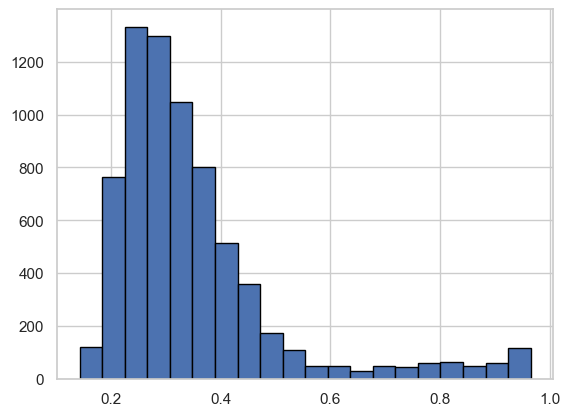

In [29]:
need_to_check["prediction_max_probability"].hist(bins=20, edgecolor="black")

In [30]:
need_to_check

,parcel_code,label_gr,label_gr_prediction,predicted_class,prediction_max_probability,prediction_needs_review,label_gr_filled,prediction_confidence_level,prediction_confidence_valid,prediction_confidence_reason,prediction_mean_borda,prediction_rank_range,prediction_mean_rank,prediction_median_rank,prediction_rank_std,prediction_rank_iqr,prediction_borda_winner,prediction_borda_winner_tied,prediction_rank_agrees_with_final,prediction_rank_confidence_level,prediction_class_oof_precision,prediction_class_oof_support,prediction_class_reliability_level,prediction_class_reliability_valid,prediction_class_reliability_reason,prediction_borda_margin,prediction_top1_agreement,prediction_top2_agreement,prediction_top3_agreement,prediction_runner_up_class,prediction_runner_up_borda,prediction_rank_models_used,prediction_rank_confidence_valid,prediction_rank_confidence_reason
4,277666998,χορτοδοτικές καλ...,σιτάρι,σιτάρι,0.4601454098,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,100.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,11.6666666667,1.0000000000,1.0000000000,1.0000000000,κριθάρι,88.3333333333,5,True,rank_confidence_...
5,277666948,χορτοδοτικές καλ...,σιτάρι,σιτάρι,0.2865884774,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,96.6666666667,1.0000000000,1.4000000000,1.0000000000,0.4898979486,1.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,1.6666666667,0.6000000000,1.0000000000,1.0000000000,κριθάρι,95.0000000000,5,True,rank_confidence_...
6,277666915,χορτοδοτικές καλ...,σιτάρι,σιτάρι,0.3488297964,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,100.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,11.6666666667,1.0000000000,1.0000000000,1.0000000000,λοιπά σιτηρά,88.3333333333,5,True,rank_confidence_...
19,142146817,χορτοδοτικές καλ...,αγρανάπαυση,αγρανάπαυση,0.2781801173,True,χορτοδοτικές καλ...,LOW,True,class_reliabilit...,96.6666666667,1.0000000000,1.4000000000,1.0000000000,0.4898979486,1.0000000000,αγρανάπαυση,False,True,HIGH,0.2161731933,3141,LOW,True,precision_below_...,11.6666666667,0.6000000000,1.0000000000,1.0000000000,λοιπά σιτηρά,85.0000000000,5,True,rank_confidence_...
22,125481020,σιτάρι,αραβόσιτος,αραβόσιτος,0.9519350643,False,σιτάρι,HIGH,True,high_rank_consen...,100.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,αραβόσιτος,False,True,HIGH,0.8397968606,2166,HIGH,True,sufficient_oof_s...,16.6666666667,1.0000000000,1.0000000000,1.0000000000,ηλίανθος,83.3333333333,5,True,rank_confidence_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28677,246837398,κριθάρι,σιτάρι,σιτάρι,0.2374462418,False,κριθάρι,MEDIUM,True,class_reliabilit...,96.6666666667,1.0000000000,1.4000000000,1.0000000000,0.4898979486,1.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,6.6666666667,0.6000000000,1.0000000000,1.0000000000,κριθάρι,90.0000000000,5,True,rank_confidence_...
28690,52655196,χορτοδοτικές καλ...,σιτάρι,σιτάρι,0.2714162645,False,χορτοδοτικές καλ...,MEDIUM,True,class_reliabilit...,96.6666666667,1.0000000000,1.4000000000,1.0000000000,0.4898979486,1.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,11.6666666667,0.6000000000,1.0000000000,1.0000000000,κριθάρι,85.0000000000,5,True,rank_confidence_...
28691,198824949,κριθάρι,σιτάρι,σιτάρι,0.4734870794,False,κριθάρι,MEDIUM,True,class_reliabilit...,100.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,σιτάρι,False,True,HIGH,0.7035164835,9100,MEDIUM,True,precision_below_...,8.3333333333,1.0000000000,1.0000000000,1.0000000000,κριθάρι,91.6666666667,5,True,rank_confidence_...
28695,219533389,σιτάρι,κριθάρι,κριθάρι,0.481313943